# Mutual Fund Performance Analytics

This notebook computes key financial performance metrics for 40 mutual fund schemes using historical NAV data, benchmark indices, and fund characteristics.

Metrics include:

- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load cleaned datasets

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

In [11]:
print("Fund Master :", fund_master.shape)

print("NAV History :", nav_history.shape)

print("Performance :", performance.shape)

print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV History : (46000, 4)
Performance : (40, 19)
Benchmark : (8050, 3)


In [4]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
nav_history = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [6]:
nav_history = nav_history.sort_values(
    ["scheme_name", "date"]
)

In [7]:
nav_history.head()

,amfi_code,date,nav,scheme_name
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth


In [8]:
print(nav_history.info())

<class 'pandas.core.frame.DataFrame'>
Index: 46000 entries, 3450 to 8049
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   amfi_code    46000 non-null  int64         
 1   date         46000 non-null  datetime64[ns]
 2   nav          46000 non-null  float64       
 3   scheme_name  46000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.8+ MB
None


In [9]:
print(nav_history.isna().sum())

amfi_code      0
date           0
nav            0
scheme_name    0
dtype: int64


In [10]:
print(nav_history.head())

      amfi_code       date       nav  \
3450     101206 2022-01-03  305.0996   
3451     101206 2022-01-04  305.4514   
3452     101206 2022-01-05  306.6324   
3453     101206 2022-01-06  305.9800   
3454     101206 2022-01-07  304.0480   

                                        scheme_name  
3450  ABSL Frontline Equity Fund - Regular - Growth  
3451  ABSL Frontline Equity Fund - Regular - Growth  
3452  ABSL Frontline Equity Fund - Regular - Growth  
3453  ABSL Frontline Equity Fund - Regular - Growth  
3454  ABSL Frontline Equity Fund - Regular - Growth  


Compute Daily Returns

In [12]:
# Calculate daily returns for each scheme

nav_history["daily_return"] = (
    nav_history
    .groupby("scheme_name")["nav"]
    .pct_change()
)

In [13]:
nav_history.head(10)

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314
3455,101206,2022-01-10,307.5591,ABSL Frontline Equity Fund - Regular - Growth,0.011548
3456,101206,2022-01-11,309.4372,ABSL Frontline Equity Fund - Regular - Growth,0.006106
3457,101206,2022-01-12,313.2022,ABSL Frontline Equity Fund - Regular - Growth,0.012167
3458,101206,2022-01-13,310.7396,ABSL Frontline Equity Fund - Regular - Growth,-0.007863
3459,101206,2022-01-14,308.9641,ABSL Frontline Equity Fund - Regular - Growth,-0.005714


In [14]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [15]:
nav_history["daily_return"].isna().sum()

np.int64(40)

# CAGR (Compound Annual Growth Rate)

CAGR measures the annualized return of a mutual fund over the available investment horizon.

In [16]:
# CAGR Calculation

cagr_results = []

for scheme, df in nav_history.groupby("scheme_name"):

    df = df.sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    start_date = df.iloc[0]["date"]
    end_date = df.iloc[-1]["date"]

    years = (end_date - start_date).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_results.append({
        "scheme_name": scheme,
        "start_nav": start_nav,
        "end_nav": end_nav,
        "years": round(years,2),
        "CAGR": cagr
    })

cagr_df = pd.DataFrame(cagr_results)

In [17]:
cagr_df["CAGR (%)"] = cagr_df["CAGR"] * 100

cagr_df = cagr_df.sort_values(
    "CAGR (%)",
    ascending=False
)

cagr_df.head(10)

,scheme_name,start_nav,end_nav,years,CAGR,CAGR (%)
18,ICICI Pru Midcap Fund - Regular - Growth,135.8720,473.7640,4.4,0.328274,32.827406
36,SBI Small Cap Fund - Regular Plan - Growth,89.8738,309.2050,4.4,0.324235,32.423536
8,DSP Small Cap Fund - Regular - Growth,81.6814,279.7511,4.4,0.322874,32.287440
26,Mirae Asset Tax Saver Fund - Regular - Growth,28.8620,97.7435,4.4,0.319495,31.949523
25,Mirae Asset Large Cap Fund - Regular - Growth,70.2514,230.2708,4.4,0.309741,30.974108
22,Kotak Flexicap Fund - Regular - Growth,49.9131,163.2397,4.4,0.309075,30.907455
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,107.3758,342.0072,4.4,0.301232,30.123153
7,DSP Midcap Fund - Regular - Growth,78.4622,245.3651,4.4,0.295811,29.581087
5,Axis Midcap Fund - Regular - Growth,68.3023,203.8581,4.4,0.282144,28.214417
33,SBI Bluechip Fund - Regular Plan - Growth,54.3856,149.3216,4.4,0.258047,25.804686


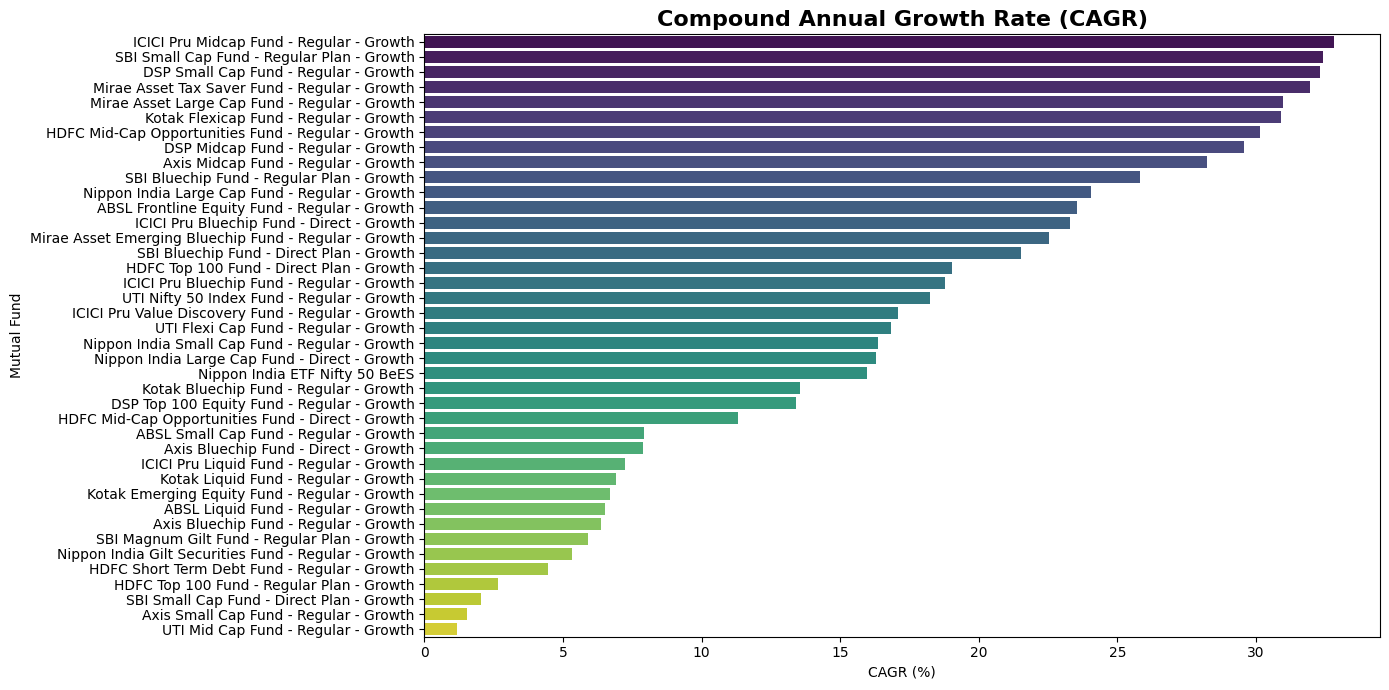

In [18]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=cagr_df,
    x="CAGR (%)",
    y="scheme_name",
    palette="viridis"
)

plt.title(
    "Compound Annual Growth Rate (CAGR)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("CAGR (%)")

plt.ylabel("Mutual Fund")

plt.tight_layout()

plt.savefig(
    "../reports/cagr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Sharpe Ratio

Risk-adjusted return using RBI Repo Rate proxy of 6.5%.

In [19]:
RISK_FREE_RATE = 0.065

In [20]:
sharpe_results = []

for scheme, df in nav_history.groupby("scheme_name"):

    returns = df["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        annual_return - RISK_FREE_RATE
    ) / annual_volatility

    sharpe_results.append({

        "scheme_name": scheme,

        "Annual Return": annual_return,

        "Annual Volatility": annual_volatility,

        "Sharpe Ratio": sharpe

    })

sharpe_df = pd.DataFrame(sharpe_results)

In [21]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
)

sharpe_df.reset_index(drop=True, inplace=True)

sharpe_df.head(10)

,scheme_name,Annual Return,Annual Volatility,Sharpe Ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.141937,1.448291
1,Kotak Flexicap Fund - Regular - Growth,0.272602,0.158870,1.306744
2,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.176740,1.234930
3,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.137414,1.208267
4,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.192909,1.180101
5,DSP Midcap Fund - Regular - Growth,0.265908,0.177462,1.132122
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.272111,0.189367,1.093699
7,Nippon India Large Cap Fund - Regular - Growth,0.218037,0.141484,1.081659
8,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.145682,1.027213
9,ICICI Pru Bluechip Fund - Direct - Growth,0.212448,0.143638,1.026524


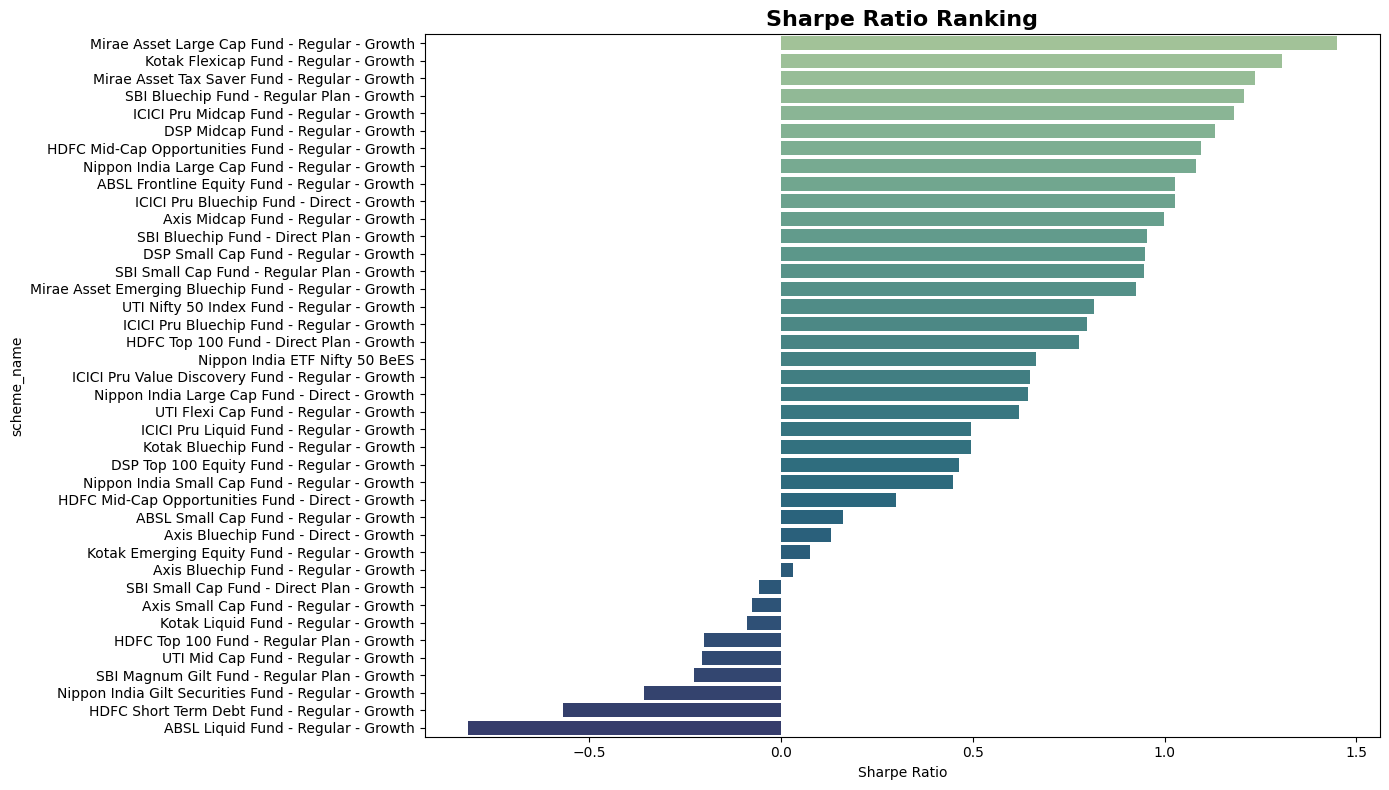

In [22]:
plt.figure(figsize=(14,8))

sns.barplot(
    data=sharpe_df,
    x="Sharpe Ratio",
    y="scheme_name",
    palette="crest"
)

plt.title(
    "Sharpe Ratio Ranking",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
performance_summary = cagr_df.merge(

    sharpe_df,

    on="scheme_name"

)

performance_summary.head()

,scheme_name,start_nav,end_nav,years,CAGR,CAGR (%),Annual Return,Annual Volatility,Sharpe Ratio
0,ICICI Pru Midcap Fund - Regular - Growth,135.8720,473.7640,4.4,0.328274,32.827406,0.292653,0.192909,1.180101
1,SBI Small Cap Fund - Regular Plan - Growth,89.8738,309.2050,4.4,0.324235,32.423536,0.302656,0.251406,0.945308
2,DSP Small Cap Fund - Regular - Growth,81.6814,279.7511,4.4,0.322874,32.287440,0.300931,0.248402,0.949796
3,Mirae Asset Tax Saver Fund - Regular - Growth,28.8620,97.7435,4.4,0.319495,31.949523,0.283262,0.176740,1.234930
4,Mirae Asset Large Cap Fund - Regular - Growth,70.2514,230.2708,4.4,0.309741,30.974108,0.270566,0.141937,1.448291


### Insights

- Higher CAGR indicates stronger annualized fund growth.
- Sharpe Ratio measures return earned per unit of total risk.
- Funds with both high CAGR and high Sharpe Ratio demonstrate strong risk-adjusted performance.

In [24]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [25]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [26]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (

    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()

)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [27]:
benchmark["benchmark_return"].describe()

count    8043.000000
mean        0.000553
std         0.008752
min        -0.039716
25%        -0.003466
50%         0.000296
75%         0.004576
max         0.041854
Name: benchmark_return, dtype: float64

In [28]:
benchmark["index_name"].unique()

array(['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100',
       'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150'], dtype=object)

In [29]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [30]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


Sortino Ratio

In [31]:
import numpy as np

rf_daily = 0.065 / 252

sortino_results = []

for scheme, group in nav_history.groupby("scheme_name"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    downside_std = downside.std() * np.sqrt(252)

    annual_return = returns.mean() * 252

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (annual_return - 0.065) / downside_std

    sortino_results.append([
        scheme,
        annual_return,
        downside_std,
        sortino
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "scheme_name",
        "Annual Return",
        "Downside Volatility",
        "Sortino Ratio"
    ]
)

sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino_df.head()

,scheme_name,Annual Return,Downside Volatility,Sortino Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.086168,2.385644
22,Kotak Flexicap Fund - Regular - Growth,0.272602,0.087806,2.364320
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.101663,2.146914
33,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.077576,2.140267
18,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.112180,2.029353


Chart — Sortino Ranking

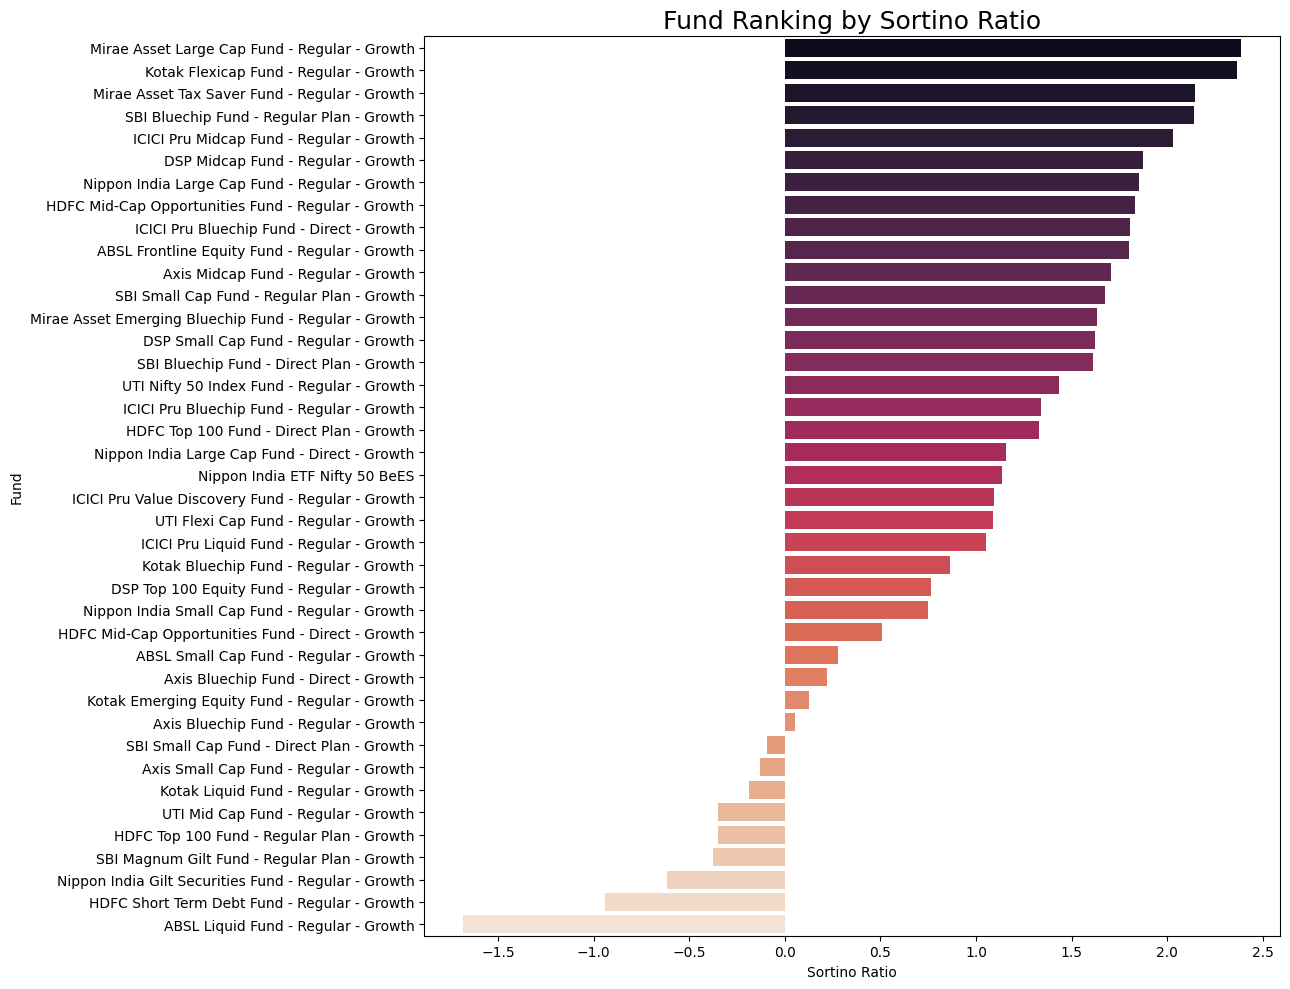

In [32]:
plt.figure(figsize=(13,10))

sns.barplot(
    data=sortino_df,
    y="scheme_name",
    x="Sortino Ratio",
    palette="rocket"
)

plt.title("Fund Ranking by Sortino Ratio", fontsize=18)

plt.xlabel("Sortino Ratio")

plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Prepare Benchmark Mapping


In [33]:
benchmark_map = {
    "NIFTY 50 TRI":"NIFTY50",
    "NIFTY 100 TRI":"NIFTY100",
    "NIFTY Midcap 150 TRI":"NIFTY_MIDCAP150",
    "BSE 250 SmallCap TRI":"BSE_SMALLCAP",
    "CRISIL Liquid Index":"CRISIL_LIQUID",
    "CRISIL Dynamic Gilt Index":"CRISIL_GILT"
}

fund_master["benchmark_clean"] = (
    fund_master["benchmark"]
    .replace(benchmark_map)
)

fund_master[
    ["scheme_name","benchmark","benchmark_clean"]
].head()

,scheme_name,benchmark,benchmark_clean
0,SBI Bluechip Fund - Regular Plan - Growth,NIFTY 100 TRI,NIFTY100
1,SBI Bluechip Fund - Direct Plan - Growth,NIFTY 100 TRI,NIFTY100
2,SBI Small Cap Fund - Regular Plan - Growth,BSE 250 SmallCap TRI,BSE_SMALLCAP
3,SBI Small Cap Fund - Direct Plan - Growth,BSE 250 SmallCap TRI,BSE_SMALLCAP
4,SBI Magnum Gilt Fund - Regular Plan - Growth,CRISIL Dynamic Gilt Index,CRISIL_GILT


Alpha & Beta

In [34]:
from scipy.stats import linregress

alpha_beta = []

for scheme in nav_history["scheme_name"].unique():

    fund = nav_history[
        nav_history["scheme_name"] == scheme
    ][["date","daily_return"]]

    bench_name = fund_master.loc[
        fund_master["scheme_name"] == scheme,
        "benchmark_clean"
    ].values[0]

    bench = benchmark[
        benchmark["index_name"] == bench_name
    ][["date","benchmark_return"]]

    merged = fund.merge(
        bench,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    beta, alpha, r, p, std = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append([
        scheme,
        alpha * 252,
        beta,
        r**2
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "scheme_name",
        "Alpha",
        "Beta",
        "R_squared"
    ]
)

alpha_beta_df.sort_values(
    "Alpha",
    ascending=False,
    inplace=True
)

alpha_beta_df.head()

,scheme_name,Alpha,Beta,R_squared
27,SBI Small Cap Fund - Regular Plan - Growth,0.315111,-0.047551,0.001754
6,DSP Small Cap Fund - Regular - Growth,0.293453,0.028550,0.000648
14,ICICI Pru Midcap Fund - Regular - Growth,0.293099,-0.001580,0.000002
17,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684,0.000463
5,DSP Midcap Fund - Regular - Growth,0.269121,-0.011374,0.000131


Export CSV

In [35]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv exported")

alpha_beta.csv exported


Maximun Drawdown

In [36]:
drawdown_results = []

for scheme, group in nav_history.groupby("scheme_name"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] /
        running_max
    ) - 1

    drawdown_results.append([
        scheme,
        drawdown.min()
    ])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "scheme_name",
        "Maximum Drawdown"
    ]
)

drawdown_df.sort_values(
    "Maximum Drawdown"
).head()

,scheme_name,Maximum Drawdown
35,SBI Small Cap Fund - Direct Plan - Growth,-0.525742
6,Axis Small Cap Fund - Regular - Growth,-0.516778
2,ABSL Small Cap Fund - Regular - Growth,-0.354469
8,DSP Small Cap Fund - Regular - Growth,-0.311719
36,SBI Small Cap Fund - Regular Plan - Growth,-0.287060


Chart 

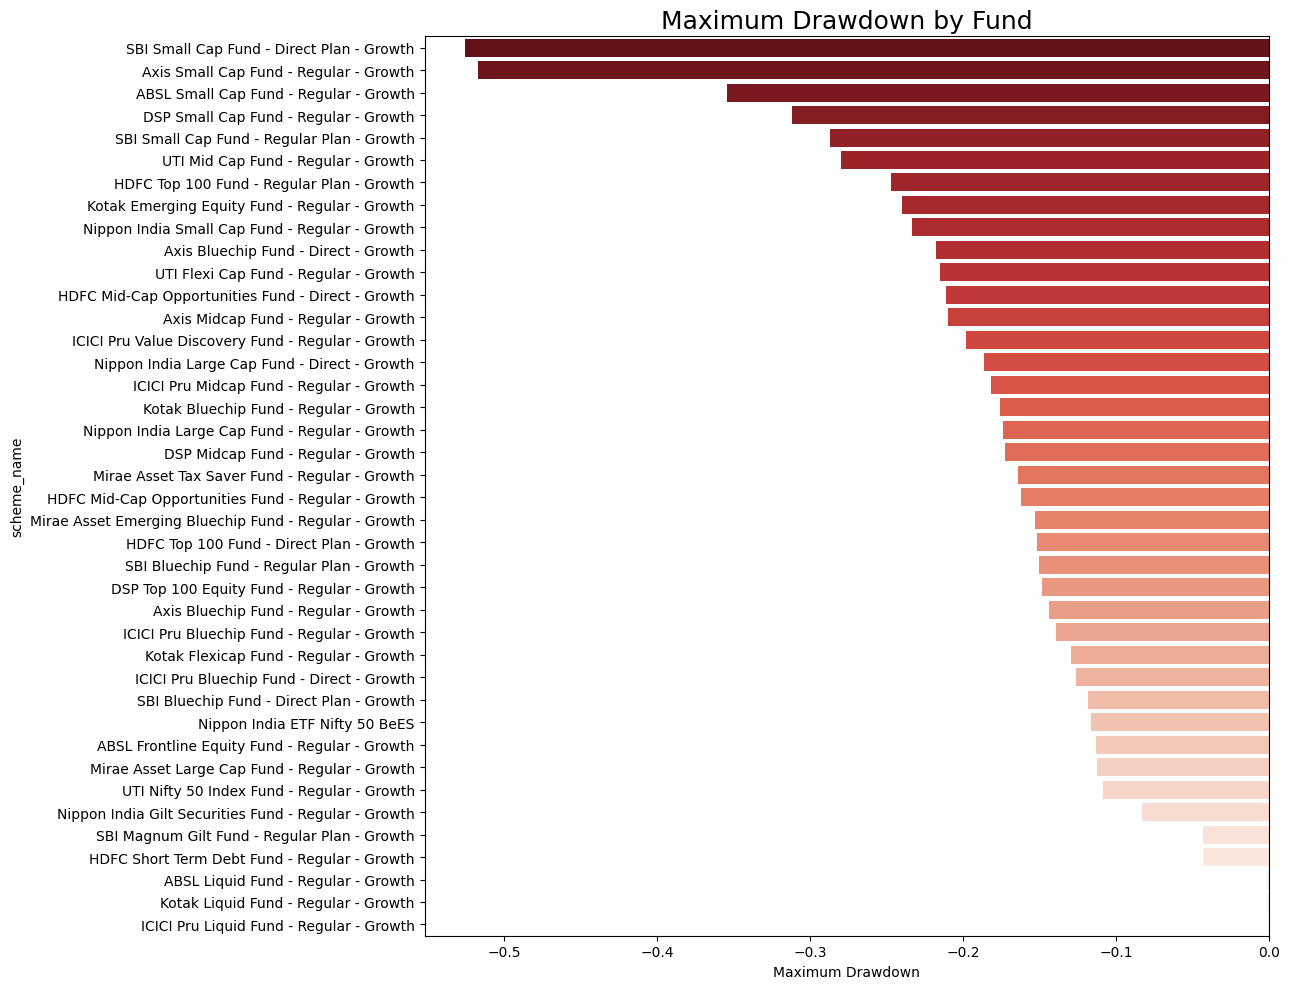

In [37]:
plt.figure(figsize=(13,10))

sns.barplot(
    data=drawdown_df.sort_values("Maximum Drawdown"),
    y="scheme_name",
    x="Maximum Drawdown",
    palette="Reds_r"
)

plt.title("Maximum Drawdown by Fund", fontsize=18)

plt.tight_layout()

plt.savefig(
    "../reports/max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Fund Scorecard (0-100)

In [38]:
scorecard = cagr_df.merge(
    sharpe_df[["scheme_name","Sharpe Ratio"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    alpha_beta_df[["scheme_name","Alpha"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="scheme_name"
)

scorecard = scorecard.merge(
    fund_master[
        ["scheme_name","expense_ratio_pct"]
    ],
    on="scheme_name"
)

Ranking


In [39]:
scorecard["Return Rank"] = scorecard["CAGR (%)"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown"].rank(ascending=False)

Composite Score 

In [40]:
scorecard["Score"] = (

30*scorecard["Return Rank"] +

25*scorecard["Sharpe Rank"] +

20*scorecard["Alpha Rank"] +

15*scorecard["Expense Rank"] +

10*scorecard["Drawdown Rank"]

)

scorecard["Score"] = (
    scorecard["Score"]
    /
    scorecard["Score"].max()
)*100

scorecard = scorecard.sort_values(
    "Score",
    ascending=False
)

scorecard.head(10)

,scheme_name,start_nav,end_nav,years,CAGR,CAGR (%),Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Score
29,UTI Mid Cap Fund - Regular - Growth,119.2905,125.5640,4.4,0.011717,1.171745,-0.205832,0.041539,-0.280011,1.51,30.0,28.0,29.0,17.5,25.0,100.000000
26,HDFC Top 100 Fund - Regular Plan - Growth,520.4608,583.6113,4.4,0.026371,2.637074,-0.201517,0.037476,-0.247344,1.55,27.0,27.0,30.0,24.0,24.0,99.721448
28,Axis Small Cap Fund - Regular - Growth,52.5238,56.1319,4.4,0.015215,1.521505,-0.075974,0.057895,-0.516778,1.38,29.0,26.0,25.0,12.5,29.0,92.757660
27,SBI Small Cap Fund - Direct Plan - Growth,96.4565,105.4849,4.4,0.020545,2.054485,-0.057187,0.047784,-0.525742,0.72,28.0,25.0,28.0,3.5,30.0,88.300836
23,Axis Bluechip Fund - Regular - Growth,38.7466,50.8387,4.4,0.063680,6.367989,0.030785,0.068995,-0.144016,1.64,24.0,24.0,24.0,30.0,10.0,87.279480
22,Kotak Emerging Equity Fund - Regular - Growth,62.1265,82.6457,4.4,0.067015,6.701543,0.076000,0.088508,-0.240035,1.56,23.0,23.0,22.0,25.0,23.0,85.793872
20,ABSL Small Cap Fund - Regular - Growth,38.5736,53.9836,4.4,0.079388,7.938765,0.162661,0.119693,-0.354469,1.53,21.0,21.0,20.0,20.5,28.0,79.572888
25,Nippon India Gilt Securities Fund - Regular - ...,30.1152,37.8243,4.4,0.053169,5.316890,-0.356630,0.051779,-0.083164,0.55,26.0,30.0,27.0,1.0,2.0,78.180130
24,SBI Magnum Gilt Fund - Regular Plan - Growth,42.1391,54.2038,4.4,0.058894,5.889419,-0.226575,0.056107,-0.043287,0.77,25.0,29.0,26.0,6.0,1.0,77.808728
21,Axis Bluechip Fund - Direct - Growth,41.8140,58.4203,4.4,0.078976,7.897558,0.129614,0.082328,-0.217514,0.75,22.0,22.0,23.0,5.0,21.0,72.609099


In [41]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv exported")

fund_scorecard.csv exported


Fund Score Chart 

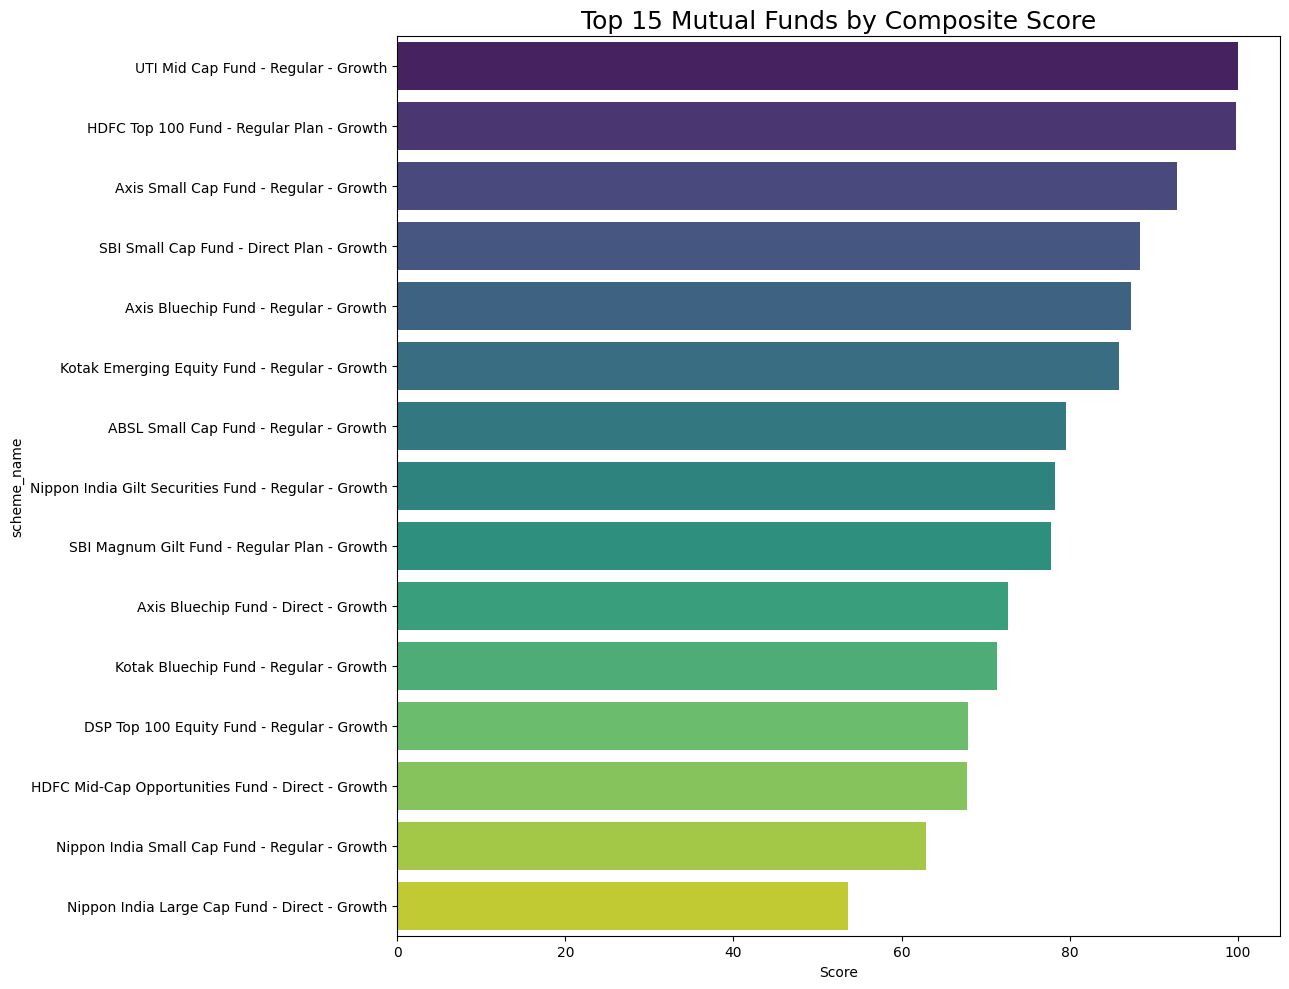

In [42]:
plt.figure(figsize=(13,10))

sns.barplot(
    data=scorecard.head(15),
    y="scheme_name",
    x="Score",
    palette="viridis"
)

plt.title(
    "Top 15 Mutual Funds by Composite Score",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "../reports/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Benchmark Comparison top 5 funds 

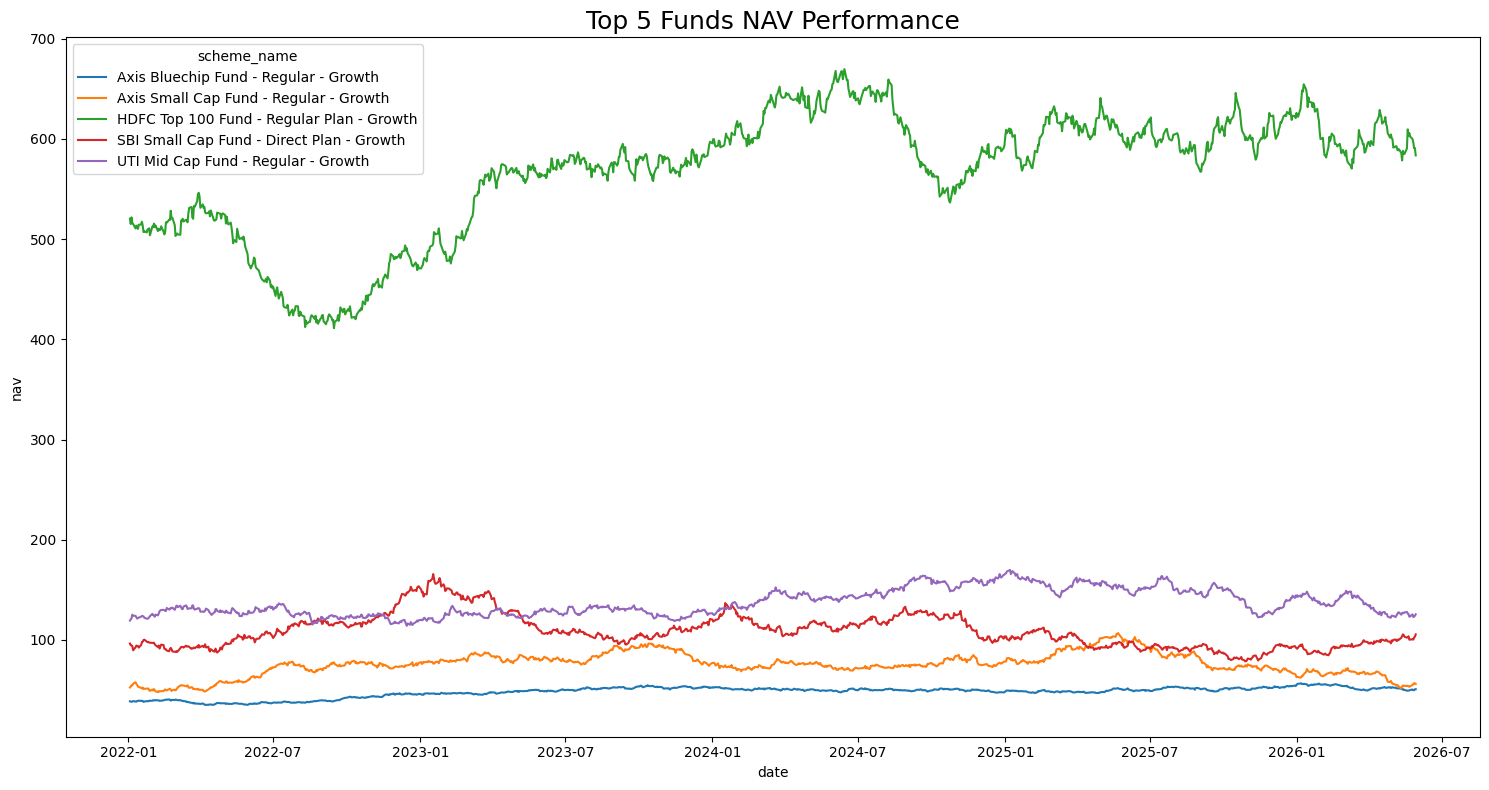

In [43]:
top5 = scorecard.head(5)["scheme_name"].tolist()

comparison = nav_history[
    nav_history["scheme_name"].isin(top5)
]

plt.figure(figsize=(15,8))

sns.lineplot(
    data=comparison,
    x="date",
    y="nav",
    hue="scheme_name"
)

plt.title(
    "Top 5 Funds NAV Performance",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()